# Lecture 9: Graph Neural Networks

<div class="alert alert-success">This notebook implements graph neural networks from scratch for molecular property prediction. We predict aqueous solubility (logS) from molecular graphs using the [ESOL dataset](https://pubs.acs.org/doi/10.1021/ci034243x) (Delaney, 2004).</div>

In [46]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt

plt.rcParams['figure.dpi'] = 100
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False

device = 'cpu'  # small graphs are faster on CPU (no transfer overhead)
print(f'Using device: {device}')

Using device: cpu


## Molecules as graphs

A molecule is naturally a graph: atoms are nodes, bonds are edges. Each atom carries features (element type, degree, charge, aromaticity) and the connectivity is encoded as an adjacency matrix.

The [ESOL dataset](https://pubs.acs.org/doi/10.1021/ci034243x) (Delaney, 2004) contains ~1128 molecules with measured aqueous solubility. We load pre-processed molecular graphs where each molecule is stored as node features and an edge index. The graphs were extracted from SMILES strings using [RDKit](https://www.rdkit.org/).

In [47]:
data = torch.load('./data/esol.pt', weights_only=False)
node_features = data['node_features']   # list of (n_atoms, 16) tensors
edge_indices = data['edge_indices']     # list of (2, n_edges) tensors
targets = data['targets']               # (1128,) tensor
smiles = data['smiles']                 # list of SMILES strings

print(f'{len(node_features)} molecules')
print(f'Feature names: {data["atom_feature_names"]}')
print(f'Example: {smiles[0]}')
print(f'  {node_features[0].shape[0]} atoms, {edge_indices[0].shape[1]} edges (incl. self-loops)')

1128 molecules
Feature names: ['C', 'N', 'O', 'F', 'S', 'Cl', 'Br', 'P', 'I', 'Na', 'other', 'degree', 'charge', 'radical_electrons', 'aromatic', 'in_ring']
Example: OCC3OC(OCC2OC(OC(C#N)c1ccccc1)C(O)C(O)C2O)C(O)C(O)C3O 
  32 atoms, 100 edges (incl. self-loops)


Text(0, 0.5, 'Atom index')

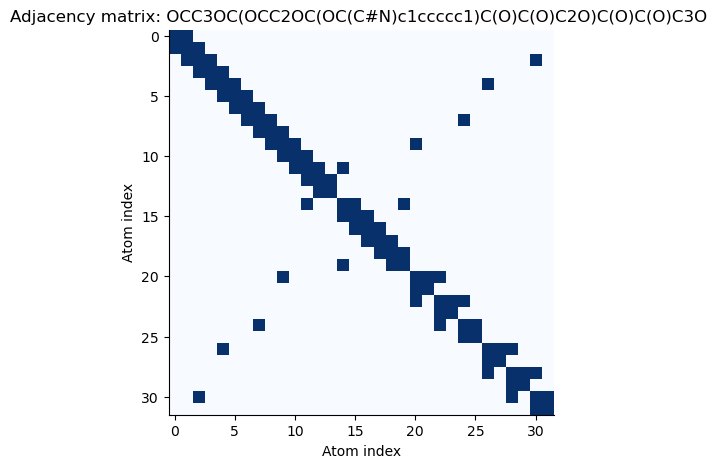

In [48]:
def edge_index_to_adj(edge_index, n):
    """Convert edge index (COO format) to adjacency matrix."""
    adj = torch.zeros(n, n)
    adj[edge_index[0], edge_index[1]] = 1
    return adj

# Visualize a molecule's adjacency matrix
idx = 0
x, ei = node_features[idx], edge_indices[idx]
adj = edge_index_to_adj(ei, x.shape[0])

fig, ax = plt.subplots(figsize=(5, 5))
ax.imshow(adj, cmap='Blues')
ax.set_title(f'Adjacency matrix: {smiles[idx]}')
ax.set_xlabel('Atom index')
ax.set_ylabel('Atom index')

In [49]:
# features
print(f'Node features for {smiles[idx]}:')
for i, name in enumerate(data['atom_feature_names']):
    print(f'  {name}: {x[:, i]}')

Node features for OCC3OC(OCC2OC(OC(C#N)c1ccccc1)C(O)C(O)C2O)C(O)C(O)C3O :
  C: tensor([0., 1., 1., 0., 1., 0., 1., 1., 0., 1., 0., 1., 1., 0., 1., 1., 1., 1.,
        1., 1., 1., 0., 1., 0., 1., 0., 1., 0., 1., 0., 1., 0.])
  N: tensor([0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.])
  O: tensor([1., 0., 0., 1., 0., 1., 0., 0., 1., 0., 1., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 1., 0., 1., 0., 1., 0., 1., 0., 1., 0., 1.])
  F: tensor([0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0.])
  S: tensor([0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0.])
  Cl: tensor([0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0.])
  Br: tensor([0., 0., 0.,

Text(0.5, 1.0, 'Molecule sizes')

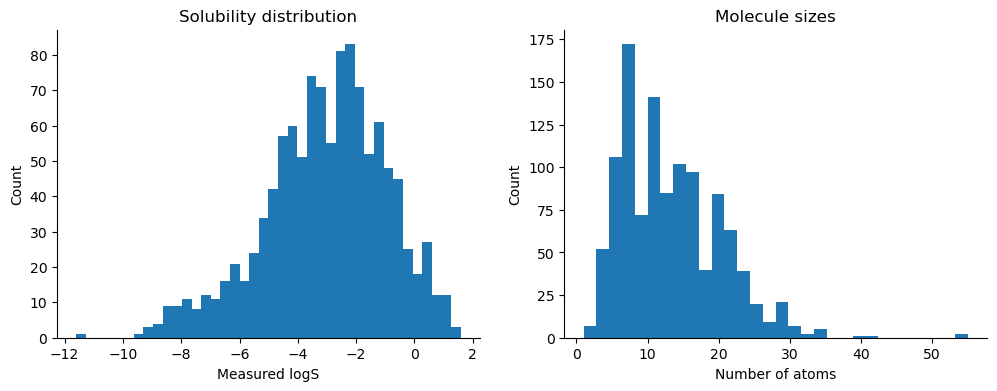

In [50]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(targets.numpy(), bins=40)
axes[0].set_xlabel('Measured logS')
axes[0].set_ylabel('Count')
axes[0].set_title('Solubility distribution')

sizes = [x.shape[0] for x in node_features]
axes[1].hist(sizes, bins=30)
axes[1].set_xlabel('Number of atoms')
axes[1].set_ylabel('Count')
axes[1].set_title('Molecule sizes')


In [51]:
# Train/test split
torch.manual_seed(42)
n_train = int(0.8 * len(node_features))
perm = torch.randperm(len(node_features))
train_idx, test_idx = perm[:n_train], perm[n_train:]

train_x = [node_features[i] for i in train_idx]
train_ei = [edge_indices[i] for i in train_idx]
train_y = targets[train_idx]
test_x = [node_features[i] for i in test_idx]
test_ei = [edge_indices[i] for i in test_idx]
test_y = targets[test_idx]

print(f'Train: {n_train}, Test: {len(test_idx)}')

Train: 902, Test: 226


## Convolutional GNN

A convolutional GNN layer performs message passing via the adjacency matrix:

$$\mathbf{H}^{(l+1)} = \sigma\left(\mathbf{D}^{-1} \mathbf{A} \mathbf{H}^{(l)} \mathbf{W}^{(l)}\right)$$

where $\mathbf{A}$ is the adjacency matrix of the graph (incl. self-loops) and $\mathbf{D}$ is its degree matrix. This is a non-linear transformation of the average of the neighboring features.

For **graph-level** predictions (e.g., molecular properties), we aggregate all node representations into a single vector via **global mean pooling**.

In [52]:
class GCNLayer(nn.Module):
    def __init__(self, in_dim, out_dim):
        super().__init__()
        self.linear = nn.Linear(in_dim, out_dim)

    def forward(self, x, A):
        D = A.sum(dim=1, keepdim=True).clamp(min=1)
        A_norm = A / D
        return self.linear(A_norm @ x)

class GCN(nn.Module):
    def __init__(self, in_dim, hidden_dim=64, n_layers=3):
        super().__init__()
        self.layers = nn.ModuleList([GCNLayer(in_dim, hidden_dim)])
        for _ in range(n_layers - 1):
            self.layers.append(GCNLayer(hidden_dim, hidden_dim))
        self.head = nn.Linear(hidden_dim, 1)

    def forward(self, x, A):
        h = x
        for layer in self.layers:
            h = F.relu(layer(h, A))
        h = h.mean(dim=0) 
        h = self.head(h)
        return h

In [53]:
def train(model, train_x, train_ei, train_y, n_epochs=30, lr=1e-3):
    optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=1e-2)
    losses = []

    for epoch in range(n_epochs):
        model.train()
        perm = torch.randperm(len(train_x))
        total_loss = 0

        for i in perm:
            x = train_x[i].to(device)
            adj = edge_index_to_adj(train_ei[i], x.shape[0]).to(device)
            y = train_y[i].to(device)

            pred = model(x, adj).squeeze()
            loss = F.mse_loss(pred, y)
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            total_loss += loss.item()

        losses.append(total_loss / len(train_x))
        if (epoch + 1) % 20 == 0:
            print(f'  epoch {epoch+1:3d}: loss={losses[-1]:.4f}')

    return losses

@torch.no_grad()
def evaluate(model, test_x, test_ei, test_y):
    model.eval()
    preds = []
    for i in range(len(test_x)):
        x = test_x[i].to(device)
        adj = edge_index_to_adj(test_ei[i], x.shape[0]).to(device)
        preds.append(model(x, adj).squeeze().cpu())
    preds = torch.stack(preds)
    rmse = (F.mse_loss(preds, test_y).item()) ** 0.5
    return preds, rmse

In [54]:
in_dim = train_x[0].shape[1]

gcn = GCN(in_dim).to(device)
print(f'Parameters: {sum(p.numel() for p in gcn.parameters()) / 1e3:.1f}K')
losses_gcn = train(gcn, train_x, train_ei, train_y)

Parameters: 9.5K
  epoch  20: loss=1.9039


Test RMSE: 1.278 logS


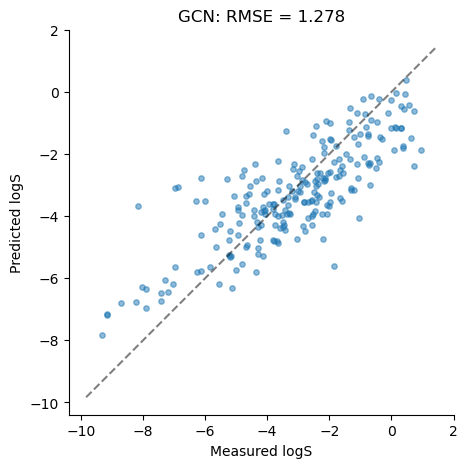

In [55]:
preds_gcn, rmse_gcn = evaluate(gcn, test_x, test_ei, test_y)
print(f'Test RMSE: {rmse_gcn:.3f} logS')

fig, ax = plt.subplots(figsize=(5, 5))
ax.scatter(test_y, preds_gcn, alpha=0.5, s=15)
lims = [min(test_y.min(), preds_gcn.min()) - 0.5, max(test_y.max(), preds_gcn.max()) + 0.5]
ax.plot(lims, lims, 'k--', alpha=0.5)
ax.set_xlabel('Measured logS')
ax.set_ylabel('Predicted logS')
ax.set_title(f'GCN: RMSE = {rmse_gcn:.3f}')
ax.set_aspect('equal')

## Attentional GNN 

Instead of fixed adjacency weights, the attentional layer learns attention coefficients between neighbors:

$$\mathbf{h}_i = \sigma\left( \sum_{j \in \mathcal{N}_i} a(\mathbf{x}_i, \mathbf{x}_j)\, \mathbf{W}^T \mathbf{x}_j \right)$$

where the attention mechanism is defined as $a(\mathbf{x}_i, \mathbf{x}_j) = \text{softmax}\left(\frac{(\mathbf{W}_Q^T \mathbf{x}_i)^T (\mathbf{W}_K^T \mathbf{x}_j)}{\sqrt{d}}\right)$, i.e. the self-attention layer of the transformer architecture, masked to the graph neighborhood.

In [56]:
class AttentionLayer(nn.Module):
    def __init__(self, in_dim, out_dim):
        super().__init__()
        self.W_Q = nn.Linear(in_dim, out_dim, bias=False)
        self.W_K = nn.Linear(in_dim, out_dim, bias=False)
        self.W_V = nn.Linear(in_dim, out_dim, bias=False)
        self.scale = out_dim ** 0.5

    def forward(self, x, adj):
        Q = self.W_Q(x)  
        K = self.W_K(x)  
        V = self.W_V(x) 

        e = (Q @ K.T) / self.scale  # (N, N)
        e = e.masked_fill(adj == 0, float('-inf'))
        alpha = F.softmax(e, dim=-1)
        return alpha @ V

class AttentionGNN(nn.Module):
    def __init__(self, in_dim, hidden_dim=64, n_layers=3):
        super().__init__()
        self.layers = nn.ModuleList([AttentionLayer(in_dim, hidden_dim)])
        for _ in range(n_layers - 1):
            self.layers.append(AttentionLayer(hidden_dim, hidden_dim))
        self.head = nn.Linear(hidden_dim, 1)

    def forward(self, x, adj):
        h = x
        for layer in self.layers:
            h = F.relu(layer(h, adj))
        h = h.mean(dim=0)
        h = self.head(h)
        return h

attn_gnn = AttentionGNN(in_dim).to(device)
print(f'Parameters: {sum(p.numel() for p in attn_gnn.parameters()) / 1e3:.1f}K')
losses_attn = train(attn_gnn, train_x, train_ei, train_y)

Parameters: 27.7K
  epoch  20: loss=1.1092


## Comparison

GCN RMSE: 1.278 logS
Attention RMSE: 1.026 logS


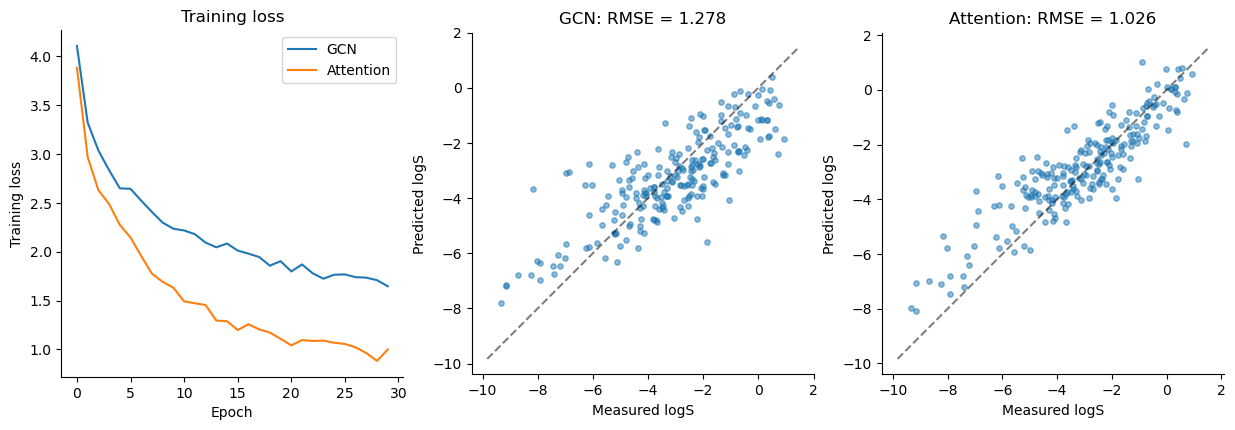

In [57]:
preds_attn, rmse_attn = evaluate(attn_gnn, test_x, test_ei, test_y)
print(f'GCN RMSE: {rmse_gcn:.3f} logS')
print(f'Attention RMSE: {rmse_attn:.3f} logS')

fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))

axes[0].plot(losses_gcn, label='GCN')
axes[0].plot(losses_attn, label='Attention')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Training loss')
axes[0].legend()
axes[0].set_title('Training loss')

for ax, p, r, name in [(axes[1], preds_gcn, rmse_gcn, 'GCN'), (axes[2], preds_attn, rmse_attn, 'Attention')]:
    ax.scatter(test_y, p, alpha=0.5, s=15)
    lims = [min(test_y.min(), p.min()) - 0.5, max(test_y.max(), p.max()) + 0.5]
    ax.plot(lims, lims, 'k--', alpha=0.5)
    ax.set_xlabel('Measured logS')
    ax.set_ylabel('Predicted logS')
    ax.set_title(f'{name}: RMSE = {r:.3f}')
    ax.set_aspect('equal')
